### İlayda Çıtak - 25531009

Sistem analiz ediliyor...
-> Analitik Global Min: x = -1.4445
-> Dinamik Sınırlar: [-2.86, 2.80]

Simülasyon Başlıyor → Dinamik Başlangıç x = 1.8845


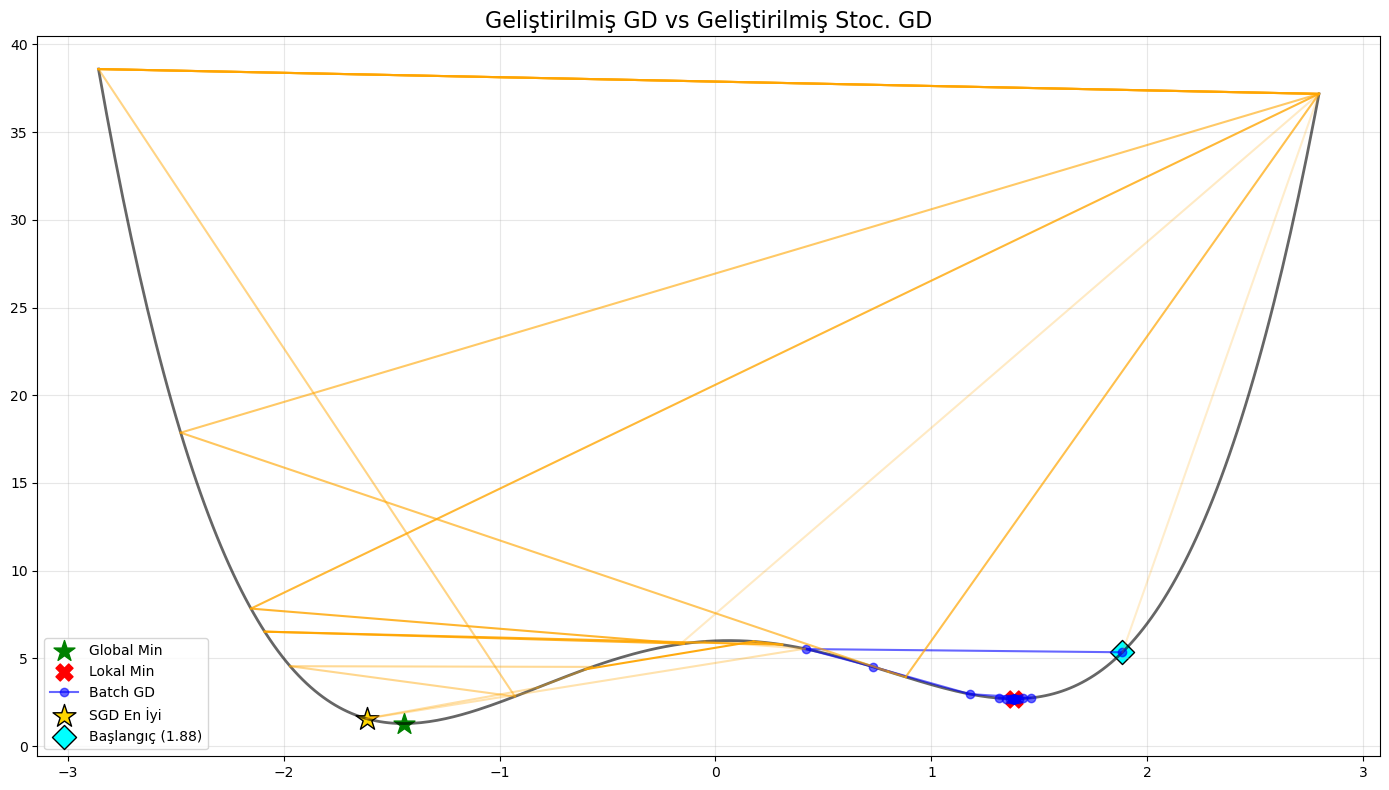


Batch Son: 1.3818149130885782 Loss: 2.6991135600284317
SGD En iyi: -1.616341843874201 Loss: 1.5670600031954134


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import random


# 1. ANALİTİK PROBLEM ÇÖZÜMÜ

x_sym = sp.symbols('x')

# --- Fonksiyon tanımı ---
f_expr = x_sym**4 - 4*x_sym**2 + 0.5*x_sym + 6  # Double-well potansiyel

# --- Otomatik türevler ---
grad_expr = sp.diff(f_expr, x_sym)
hess_expr = sp.diff(grad_expr, x_sym)

# --- Nümerik fonksiyonlar ---
f_func = sp.lambdify(x_sym, f_expr, 'numpy')
grad_func = sp.lambdify(x_sym, grad_expr, 'numpy')
hess_func = sp.lambdify(x_sym, hess_expr, 'numpy')

print("Sistem analiz ediliyor...")

# --- Analitik kritik noktalar ---
global_min = None
local_mins = []
all_critical_x = []

try:
    # --- Kökleri bul ---
    p = sp.Poly(grad_expr, x_sym)
    coeffs = [float(c) for c in p.all_coeffs()]
    roots = np.roots(coeffs)

    minima = []
    for r in roots:
        if np.isreal(r):
            val = float(np.real(r))
            all_critical_x.append(val)

            # Minumum mu? Hessian > 0 ise
            if hess_func(val) > 0:
                minima.append((val, f_func(val)))

    # --- Minimumları sırala ---
    minima.sort(key=lambda p: p[1])
    global_min = minima[0]
    local_mins = minima[1:]

    print(f"-> Analitik Global Min: x = {global_min[0]:.4f}")

except:
    print("Analitik sorun → varsayılan kritik noktalar kullanılıyor.")
    global_min = (-1.4729, 1.2859)
    local_mins = [(1.2845, 2.8600)]
    all_critical_x = [-1.4729, 0.06, 1.2845]

# --- Dinamik grafik sınırları ---
x_min_crit = min(all_critical_x)
x_max_crit = max(all_critical_x)
dist = max(2.0, x_max_crit - x_min_crit)
X_LIMIT_MIN = x_min_crit - dist * 0.5
X_LIMIT_MAX = x_max_crit + dist * 0.5

print(f"-> Dinamik Sınırlar: [{X_LIMIT_MIN:.2f}, {X_LIMIT_MAX:.2f}]")


# 2. GELİŞTİRİLMİŞ GD

def smart_batch_gd(start_x, initial_lr, lr_decay, max_steps, tolerance):
    """Deterministik gradient descent"""
    x = start_x
    lr = initial_lr
    path = [x]

    for t in range(max_steps):
        # --- Gradient hesapla ---
        grad = grad_func(x)
        grad = np.clip(grad, -50, 50)  # Çok büyük gradyanları kırp

        # --- Parametre güncelle ---
        x_new = x - lr * grad
        x_new = np.clip(x_new, X_LIMIT_MIN, X_LIMIT_MAX)
        path.append(x_new)

        # --- Durdurma kriteri ---
        if abs(x_new - x) < tolerance:
            break

        x = x_new
        lr *= lr_decay  # Non-konveks için LR decay

    return np.array(path), x


# 3. GELİŞTİRİLMİŞ STOCHASTIC GD (Temperature-based noise + LR decay + Best-los) 

def smart_sgd_annealing(start_x, initial_lr, lr_decay,
                        initial_noise, noise_decay,
                        max_steps, patience_limit=20,
                        min_loss_improve=1e-5):

    x = start_x
    lr = initial_lr
    sigma = initial_noise

    best_x = x
    best_loss = f_func(x)
    patience = 0
    path = [x]

    for t in range(max_steps):
        # --- Gradient ---
        grad = grad_func(x)
        grad = np.clip(grad, -50, 50)

        # --- Temperature-based noise ---
        noise = np.random.normal(0, sigma)

        # --- Parametre güncelle ---
        x = x - lr * (grad + noise)
        x = np.clip(x, X_LIMIT_MIN, X_LIMIT_MAX)
        path.append(x)

        # --- Loss hesapla ---
        loss = f_func(x)

        # --- Best-loss tabanlı patience ---
        if loss < best_loss - min_loss_improve:
            best_loss = loss
            best_x = x
            patience = 0  # Yeni en iyi bulundu, patience sıfırlanır
        else:
            patience += 1  # İyileşme yoksa patience artır

        # --- Early stopping ---
        if patience >= patience_limit:
            break

        # --- LR ve Noise annealing ---
        lr *= lr_decay
        sigma *= noise_decay

    return np.array(path), best_x


# 4. DİNAMİK BAŞLANGIÇ NOKTASI

if local_mins:
    trap_x = local_mins[0][0]
    # Sağdaki tepe noktasını bul (barrier)
    peak_x_candidates = [x for x in all_critical_x if x > trap_x]
    peak_x = min(peak_x_candidates) if peak_x_candidates else X_LIMIT_MAX
    # Dinamik rastgele başlangıç
    start_x = random.uniform(trap_x, peak_x)
else:
    start_x = random.uniform(X_LIMIT_MIN, X_LIMIT_MAX)

print(f"\nSimülasyon Başlıyor → Dinamik Başlangıç x = {start_x:.4f}")


# 5. ÇALIŞTIRMA

# Batch GD
path_batch, final_batch = smart_batch_gd(
    start_x,
    initial_lr=0.12,
    lr_decay=0.995,
    max_steps=150,
    tolerance=1e-4
)

# Stochastic GD
path_sgd, best_sgd = smart_sgd_annealing(
    start_x,
    initial_lr=0.12,
    lr_decay=0.998,
    initial_noise=18.0,
    noise_decay=0.96,
    max_steps=350
)


# 6. GÖRSELLEŞTİRME

plt.figure(figsize=(14, 8))

# X ekseni
x_grid = np.linspace(X_LIMIT_MIN, X_LIMIT_MAX, 300)
y_grid = f_func(x_grid)
plt.plot(x_grid, y_grid, 'k-', linewidth=2, alpha=0.6)

# Global minimum
plt.scatter([global_min[0]], [global_min[1]], c='green', 
            s=250, marker='*', label='Global Min')

# Lokal minimumlar
for lm in local_mins:
    plt.scatter([lm[0]], [lm[1]], c='red', s=150, marker='X', label='Lokal Min')

# Batch GD yolu
plt.plot(path_batch, f_func(path_batch), 'bo-', alpha=0.6, label='Batch GD')

# SGD yolu (alpha değişimi ile)
for i in range(len(path_sgd)-1):
    a = 0.2 + 0.8 * (i / len(path_sgd))
    plt.plot(path_sgd[i:i+2], f_func(path_sgd[i:i+2]), color='orange', alpha=a)

# En iyi SGD noktası
plt.scatter(best_sgd, f_func(best_sgd), c='gold', s=300, marker='*', 
            edgecolors='black', label='SGD En İyi')
plt.scatter([start_x], [f_func(start_x)], c='cyan', s=150, marker='D', 
            edgecolors='black', label=f'Başlangıç ({start_x:.2f})')

plt.title("Geliştirilmiş GD vs Geliştirilmiş Stoc. GD", fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("\nBatch Son:", final_batch, "Loss:", f_func(final_batch))
print("SGD En iyi:", best_sgd, "Loss:", f_func(best_sgd))
